## <center><font color=navy>Data Science for Quantitative Finance</font></center>
### <center>Monte Carlo Methods for Finance</center>
### <center> Ali Habibnia</center>

    
<center> Assistant Professor, Department of Economics, </center>
<center> and Division of Computational Modeling & Data Analytics at Virginia Tech</center>
 <center> habibnia@vt.edu </center> 

### An Overview of Monte Carlo Methods

- Monte Carlo method is a technique that uses random numbers and probability to solve complex problems. The Monte Carlo simulation, or probability simulation, is a parametric simulation technique used to understand the impact of risk and uncertainty in financial sectors, project management, costs, and other forecasting machine learning models.

- Risk analysis is part of almost every decision we make, as we constantly face uncertainty, ambiguity, and variability in our lives. Moreover, even though we have unprecedented access to information, we cannot accurately predict the future.

- The Monte Carlo simulation allows us to see all the possible outcomes of our decisions and assess risk impact, in consequence allowing better decision making under uncertainty.

- The concept was developed in the 1940s by Stanislaw Ulam, a mathematician who devised these methods as part of his contribution to the Manhattan Project. The name is a reference to the famous casino in Monaco, highlighting the element of randomness involved. He used the tools of random sampling and inferential statistics to model likelihoods of outcomes, originally applied to a card game (Monte Carlo Solitaire). Ulam later worked with collaborator John von Neumann, using newly developed computer technologies to run simulations to better understand the risks associated with the nuclear project.

#### Mathematical Definition:
Given a quantity of interest $\theta = \mathbb{E}[f(X)]$, where $X$ is a random variable, and $f$ is a function, Monte Carlo estimates this expectation as:

$$
\hat{\theta}_n = \frac{1}{n} \sum_{i=1}^n f(X_i)
$$

where $X_1, ..., X_n \sim \text{i.i.d. from } X$.

As $n \to \infty$, the Law of Large Numbers ensures that $\hat{\theta}_n \to \theta$.


### Illustrative Example: Coin Flipping Simulation

Consider the classic example of a fair coin flip, where the outcomes are either heads or tails, each with probability 0.5. While theoretically trivial, this example illustrates key properties of Monte Carlo estimation:

- The convergence to the true probability (Law of Large Numbers)
- The nature of sampling variability
- The construction of confidence intervals empirically

Let $X_i = 1$ if the $i$-th flip is a head and $0$ otherwise. Then $\hat{p}_n = \frac{1}{n} \sum_{i=1}^n X_i$ estimates $\mathbb{P}(\text{head}) = 0.5$.


Final value : 0.496
Process time : 1.0625


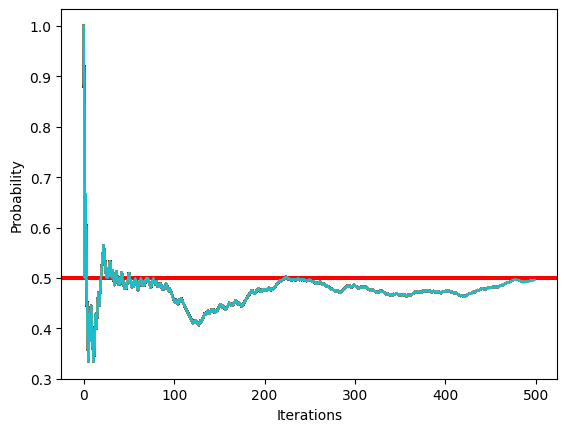

In [3]:
#Import required libraries :

import random
import numpy as np
import matplotlib.pyplot as plt
import time

#Coin flip function :

#0 --> Heads
#1 --> Tails

def coin_flip():
    return random.randint(0,1) 
    
#Check the return value of coin_flip() :

coin_flip()

#Monte Carlo Simulation :

#Empty list to store the probability values.
list1 = []

def monte_carlo(n):
    results = 0
    for i in range(n):
        flip_result = coin_flip()
        results = results + flip_result
        
        #Calculating probability value :
        prob_value = results/(i+1)
        
        #Append the probability values to the list :
        list1.append(prob_value)

        #Plot the results :
        plt.axhline(y=0.5, color='r', linestyle='-')
        plt.xlabel("Iterations")
        plt.ylabel("Probability")
        plt.plot(list1)
       
    return results/n
    
    #Calling the function :

tic = time.process_time()
answer = monte_carlo(500)
print("Final value :",answer)
toc = time.process_time()
print("Process time :",toc - tic)

As shown in above figure, we show that after 500 iterations, the probability of getting a tail is 0.502. Consequently, this is how we can use the Monte Carlo Simulation to find probabilities experimentally.

#### Estimating PI using circle and square:

To estimate the value of PI, we need the area of the square and the area of the circle. To find these areas, we will randomly place dots on the surface and count the dots that fall inside the circle and dots that fall inside the square. Such will give us an estimated amount of their areas. Therefore instead of using the actual areas, we will use the count of dots to use as areas.

Area of square = $(2r)^2$

Area of circle = $\pi r^2$

Final estimated π after 50000 samples: 3.140800


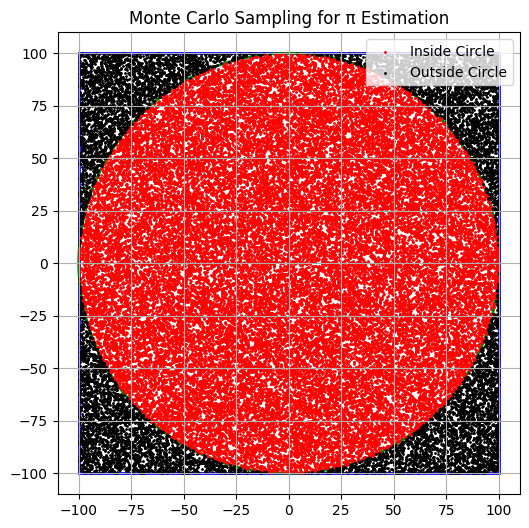

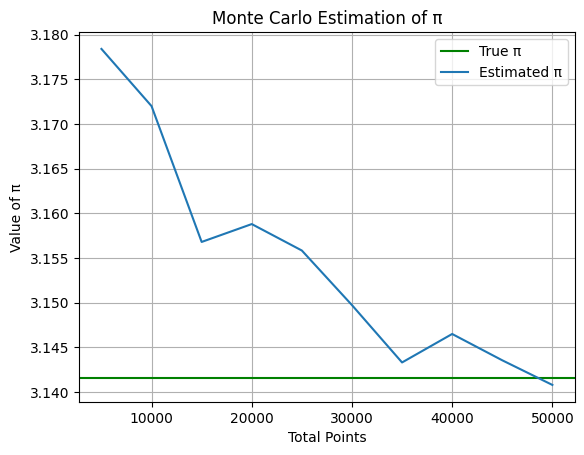

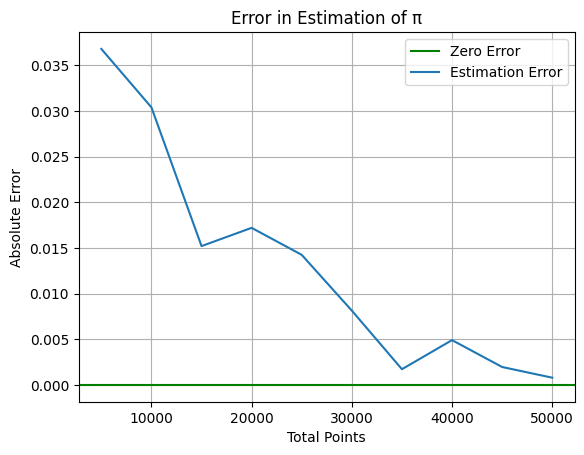

In [15]:
import random
import matplotlib.pyplot as plt
import math
from concurrent.futures import ThreadPoolExecutor
import numpy as np

def generate_points(n_points, radius):
    in_points = []
    out_points = []
    in_c = 0
    out_c = 0

    for _ in range(n_points):
        x = random.uniform(-radius, radius)
        y = random.uniform(-radius, radius)
        if x**2 + y**2 <= radius**2:
            in_c += 1
            in_points.append((x, y))
        else:
            out_c += 1
            out_points.append((x, y))

    return in_c, out_c, in_points, out_points

# Parameters
radius = 100
iterations = 10
points_per_iteration = 5000

all_pi_values = []
all_errors = []
all_in_points = []
all_out_points = []
total_in = 0
total_out = 0

with ThreadPoolExecutor() as executor:
    futures = [executor.submit(generate_points, points_per_iteration, radius) for _ in range(iterations)]

    for future in futures:
        in_c, out_c, in_pts, out_pts = future.result()
        total_in += in_c
        total_out += out_c
        all_in_points.extend(in_pts)
        all_out_points.extend(out_pts)

        total_points = total_in + total_out
        pi_estimate = 4.0 * total_in / total_points
        error = abs(math.pi - pi_estimate)

        all_pi_values.append(pi_estimate)
        all_errors.append(error)

print(f"Final estimated π after {iterations * points_per_iteration} samples: {all_pi_values[-1]:.6f}")

# -- Visualization 1: Square, Circle, and Sampled Points --

fig, ax = plt.subplots(figsize=(6,6))

# Draw the square
square = plt.Rectangle((-radius, -radius), 2*radius, 2*radius, edgecolor='blue', facecolor='none', linewidth=2)
ax.add_patch(square)

# Draw the circle
circle = plt.Circle((0, 0), radius, edgecolor='green', facecolor='none', linewidth=2)
ax.add_patch(circle)

# Plot in-circle and out-of-circle points
if all_in_points:
    x_in, y_in = zip(*all_in_points)
    ax.scatter(x_in, y_in, color='red', s=1, label='Inside Circle')

if all_out_points:
    x_out, y_out = zip(*all_out_points)
    ax.scatter(x_out, y_out, color='black', s=1, label='Outside Circle')

ax.set_aspect('equal')
ax.set_xlim(-radius-10, radius+10)
ax.set_ylim(-radius-10, radius+10)
ax.set_title('Monte Carlo Sampling for π Estimation')
ax.legend(loc='upper right')
plt.grid(True)
plt.show()

# -- Visualization 2: Convergence of π --

plt.figure()
plt.axhline(y=math.pi, color='g', linestyle='-', label='True π')
plt.plot(np.arange(1, iterations + 1) * points_per_iteration, all_pi_values, label='Estimated π')
plt.xlabel("Total Points")
plt.ylabel("Value of π")
plt.title("Monte Carlo Estimation of π")
plt.legend()
plt.grid(True)
plt.show()

# -- Visualization 3: Estimation Error --

plt.figure()
plt.axhline(y=0.0, color='g', linestyle='-', label='Zero Error')
plt.plot(np.arange(1, iterations + 1) * points_per_iteration, all_errors, label='Estimation Error')
plt.xlabel("Total Points")
plt.ylabel("Absolute Error")
plt.title("Error in Estimation of π")
plt.legend()
plt.grid(True)
plt.show()


As shown in figure, we can see that after 5000 iterations, we can get the approximate value of PI. Also, notice that the error in estimation also decreased exponentially as the number of iterations increased.

#### Why Does the House Always Win?

How do casinos earn money? The trick is straightforward — **“The more you play, the more they earn.”** 

Let us take a look at how this works with a simple Monte Carlo Simulation example.

Consider an imaginary game in which a player has to choose a chip from a bag of chips.

**Rules:**

1. There are chips containing numbers ranging from 1–100 in a bag.

2. Users can bet on even or odd chips.

3. In this game, 10 and 11 are special numbers. If we bet on evens, then 10 will be counted as an odd number, and if we bet on odds, then 11 will be counted as an even number.

4. If we bet on even numbers and we get 10 then we lose.

5. If we bet on odd numbers and we get 11 then we lose.

If we bet on odds, the probability that we will win is of 49/100. The probability that the house wins is of 51/100. Therefore, for an odd bet the house edge is = 51/100–49/100 = 200/10000 = 0.02 = 2%

If we bet on evens, the probability that the user wins is of 49/100. The probability that the house wins is of 51/100. Hence, for an odd bet the house edge is = 51/100–49/100 = 200/10000 = 0.02 = 2%

In summary, for every $ 1 bet, $ 0.02 goes to the house. In comparison, the lowest house edge on roulette with a single 0 is 2.5%. Consequently, we are certain that you will have a better chance of winning at our imaginary game than with roulette.


Do you want to bet on Even or Odd? 
 Odd


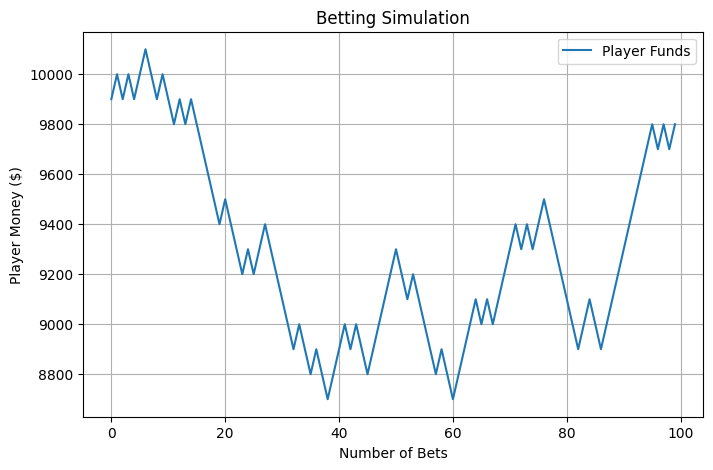


Number of bets = 5
Average ending money after 10 runs: $10020.00

Number of bets = 10
Average ending money after 10 runs: $9980.00

Number of bets = 50
Average ending money after 10 runs: $9880.00

Number of bets = 100
Average ending money after 10 runs: $9680.00

Number of bets = 1000
Average ending money after 10 runs: $7240.00

Number of bets = 5000
Average ending money after 10 runs: $-3020.00

Number of bets = 10000
Average ending money after 10 runs: $-8960.00


In [17]:
import random
import matplotlib.pyplot as plt

# --- Game Rules Description (Kept for clarity as comment) ---
"""
RULES:
1. There are chits containing numbers ranging from 1-100 in a bag.
2. Users can bet on even or odd.
3. In this game, 10 is a special odd number and 11 is a special even number.
4. If you bet on even and get 10 → you lose.
5. If you bet on odd and get 11 → you lose.
"""

# --- Ask user for bet choice (Even or Odd) ---
choice = input("Do you want to bet on Even or Odd? \n").strip().lower()

# --- Define pickNote function based on user's choice ---
def get_pick_function(choice):
    if choice == "even":
        def pickNote():
            note = random.randint(1, 100)
            return note % 2 == 0 and note != 10
        return pickNote

    elif choice == "odd":
        def pickNote():
            note = random.randint(1, 100)
            return note % 2 == 1 and note != 11
        return pickNote
    else:
        raise ValueError("Invalid choice. Please enter 'Even' or 'Odd'.")

pickNote = get_pick_function(choice)

# --- Game simulation function ---
def play(total_money, bet_money, total_plays, track_plot=False):
    num_of_plays = []
    money = []
    final_funds = total_money

    for play_number in range(total_plays):
        if pickNote():  # Win
            final_funds += bet_money
        else:  # Lose
            final_funds -= bet_money

        if track_plot:
            num_of_plays.append(play_number)
            money.append(final_funds)

    if track_plot:
        plt.figure(figsize=(8, 5))
        plt.plot(num_of_plays, money, label="Player Funds")
        plt.xlabel("Number of Bets")
        plt.ylabel("Player Money ($)")
        plt.title("Betting Simulation")
        plt.grid(True)
        plt.legend()
        plt.show()

    return final_funds

# --- Run experiments with various settings ---
def run_experiments():
    initial_money = 10000
    bet_amount = 100

    # Different bet counts to test
    bet_counts = [5, 10, 50, 100, 1000, 5000, 10000]

    for bets in bet_counts:
        results = []
        for _ in range(10):
            ending_money = play(initial_money, bet_amount, bets)
            results.append(ending_money)

        average_final = sum(results) / len(results)
        print(f"\nNumber of bets = {bets}")
        print(f"Average ending money after 10 runs: ${average_final:.2f}")

# Optional: run a single plotted game
_ = play(10000, 100, 100, track_plot=True)

# Run the simulations
run_experiments()

# Monte Carlo Methods in Financial Applications

Monte Carlo methods refer to a broad class of computational algorithms that rely on repeated random sampling to obtain numerical results. In finance, these methods are particularly useful in cases where analytical solutions are intractable, and uncertainty or stochastic behavior plays a central role.

#### Key Uses in Finance:
- Option pricing (especially for path-dependent derivatives like Asian or Barrier options)
- Risk management and Value-at-Risk (VaR) estimation
- Portfolio optimization under uncertainty
- Forecasting future asset prices or returns
- Simulating stochastic processes (e.g., geometric Brownian motion)

The importance of risk is another large factor in why financial analysts use MC methods. One relatively straightforward application of Monte Carlo in this field is portfolio optimization. When picking a portfolio of stocks, you may be willing to take on different levels of risk depending on your goals. But regardless of your willingness to accept risk, you can maximize your returns per volatility of the portfolio by using Monte Carlo to find the optimal combinations and proportions of stocks. Using historical data one can generate hundreds of thousands of different combinations of stocks in different ratios, to see how each each would perform relative to each other during that time period. Then one can choose the optimal configuration using a metric called a Sharpe ratio (a measure of the performance of an investment’s returns given its risk.)

#### Securities Pricing

In general, the market price of any security should represent the present value of all future cash flows generated by that security. Consider the following investment vehicle:

Security A

- Pays $100 at the end of year 1

- Pays $100 at the end of year 2

- Pays $100 at the end of year 3

How much should you be willing to pay for Security A? Well, now that we know money is valued differently at different points in time we can use an appropriate risk-free rate to discount the value of each cash flow to the current point in time to determine the price of the security. Assuming the annual risk-free rate of return is 1% we can discount each of the payments to the present.


First Year’s Payment in Today’s Dollars

- 100/(1.01) = 99.01

Second Year’s Payment in Today’s Dollars

- 100/(1.01)² = 98.03

Third Year’s Payment in Today’s Dollars

- 100/(1.01)³ = 97.06

Sum of the Present Value of Future Cash Flows

- $97.06 + $98.03 + $99.01 = $294.10

Therefore, the appropriate value of Security A today is $294.10. We can generalize this concept to find the fair value for any security, regardless of how unique or exotic their payoff structure. However, using this notion of the present value of future cash flows we can find the appropriate price of said securities today (more specifically, the expected present value of future cash flows today). In order to do so, we are going to need a method of modeling stochastic movements in the underlying asset.

#### Geometric Brownian Motion

You may be familiar with Brownian Motion from high school physics. That is the seemingly random motion of air particles as they collide with each other. While we might not be able to characterize the behavior of a single particle, physics and statistics gives us the ability to still describe the likelihoods of where the overall system will end up. See https://en.wikipedia.org/wiki/Brownian_motion

Much in the same way, the Geometric Brownian Motion is a model of an assets returns where the price (or returns) of the asset / shares / investment can be modelled as a random walk (I.e a process where changes in stock prices have the same distribution and are independent of each other. Therefore, it assumes the past movement or trend of a stock price or market cannot be used to predict its future movement (Source : Investopedia)

Geometric Brownian motion is a stochastic process that can be used to generate sample paths that the underlying equity may follow. Rather than dive headlong into some reasonably complex stochastic differential equations , an intuition of how it works is


- Yt — Stock price at time t

- dYt — Change in stock price from time t

- μ — Drift term

- σ — Volatility term (the standard deviation of returns)

- dt — Change in time

- W - The Wiener Process random variable where increments in t time have a normal distribution N that is centered at zero. It is often also called Brownian motion due to its historical connection with the physical process of the same name originally observed by Scottish botanist Robert Brown. It is one of the best known Lévy processes (càdlàg stochastic processes with stationary independent increments) and occurs frequently in pure and applied mathematics, economics, quantitative finance, evolutionary biology, and physics. 

https://en.wikipedia.org/wiki/Wiener_process


Essentially, the GBM model allow us to model future prices based a combination of a “drift” that is driven by the average (i.e mean of the log returns) and a “shock” which is random but can be still be characterized by the volatility (i.e the standard deviation of the log returns).

There appear to be many components to geometric Brownian motion, but there are essentially three components: the return (dYt/Yt), the expected return (μdt), and the shocks to the return (σdWt). We can model geometric Brownian motion in Python very easily using the following code.

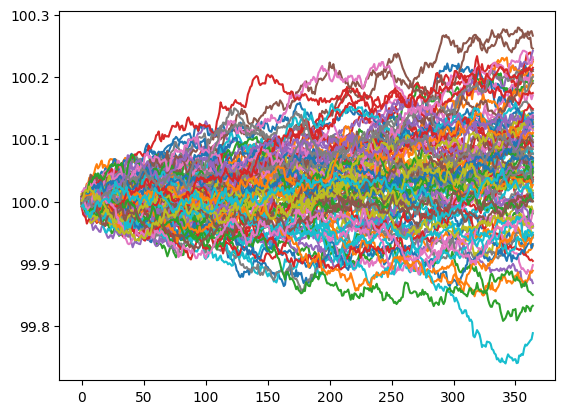

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import math


class GeometricBrownianMotion:

    def simulate_paths(self):
        while(self.T - self.dt > 0):
            dWt = np.random.normal(0, math.sqrt(self.dt))  # Brownian motion
            dYt = self.drift*self.dt + self.volatility*dWt  # Change in price
            self.current_price += dYt  # Add the change to the current price
            self.prices.append(self.current_price)  # Append new price to series
            self.T -= self.dt  # Accound for the step in time

    def __init__(self, initial_price, drift, volatility, dt, T):
        self.current_price = initial_price
        self.initial_price = initial_price
        self.drift = drift
        self.volatility = volatility
        self.dt = dt
        self.T = T
        self.prices = []
        self.simulate_paths()

# Model Parameters
paths = 100
initial_price = 100
drift = .08
volatility = .1
dt = 1/365
T = 1
price_paths = []

# Generate a set of sample paths
for i in range(0, paths):
    price_paths.append(GeometricBrownianMotion(initial_price, drift, volatility, dt, T).prices)

# Plot the set of generated sample paths
for price_path in price_paths:
    plt.plot(price_path)
plt.show()

When using geometric Brownian motion to model an equity we only need to provide a few parameters: initial stock price, drift (expected return) of the equity for time period T, volatility of the equity for time period T, the length of the time steps dt, and the total time we are generating to T. In the code above we use the following parameter set…

- Initial Price — 100

- Drift — 8% (expected return)

- Volatility — 10% (expected shock to return)

- Time Steps (dt) — 1/365 (daily)

- Total Time (T) — 1 (one year)

If using geometric Brownian motion to generate sample paths for a real equity, there are a few ways you can go about finding drift and volatility. Generally, I use the average historical return for the time period T I am generating for, and volatility I use the implied volatility for an at the money option. After running the code above we end up generating 100 sample paths that can be plotted using matplotlib.

### Generate correlated data in Python

numpy.random.multivariate_normal is the function for drawing random samples from a multivariate normal distribution.

Let's assume that daily returns are distributed Multivariate Normal with mean vector $μ$ and the covariance matrix $Σ$. In other words,

$R_t ∼ MVN(μ,Σ)$

For simplicity we will only consider three assets.

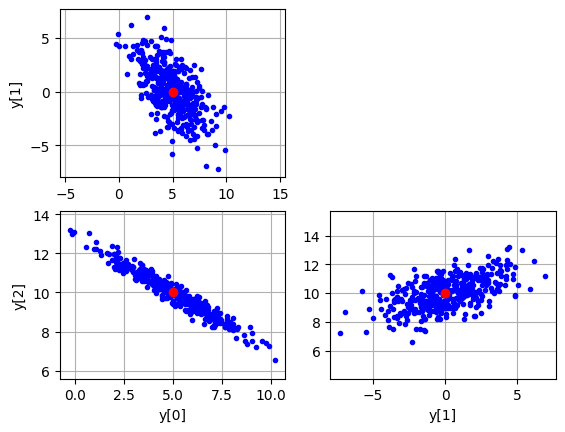

In [20]:
import numpy as np
import matplotlib.pyplot as plt


num_samples = 400

# The desired mean values of the sample.
mu = np.array([5.0, 0.0, 10.0])

# The desired covariance matrix.
cov = np.array([
        [  3.40, -2.75, -2.00],
        [ -2.75,  5.50,  1.50],
        [ -2.00,  1.50,  1.25]
    ])

# Generate the random samples.
y = np.random.multivariate_normal(mu, cov, size=num_samples)


# Plot various projections of the samples.
plt.subplot(2,2,1)
plt.plot(y[:,0], y[:,1], 'b.')
plt.plot(mu[0], mu[1], 'ro')
plt.ylabel('y[1]')
plt.axis('equal')
plt.grid(True)

plt.subplot(2,2,3)
plt.plot(y[:,0], y[:,2], 'b.')
plt.plot(mu[0], mu[2], 'ro')
plt.xlabel('y[0]')
plt.ylabel('y[2]')
plt.axis('equal')
plt.grid(True)

plt.subplot(2,2,4)
plt.plot(y[:,1], y[:,2], 'b.')
plt.plot(mu[1], mu[2], 'ro')
plt.xlabel('y[1]')
plt.axis('equal')
plt.grid(True)

plt.show()

### Cholesky Decomposition and its importance in Quantitative Finance

- Cholesky Decomposition plays a very important role in Quantitative Finance, especially in the Derivatives pricing and portfolio cunstruction were we are dealing with multiple correlated assets. 

- When we are trying to Model Products whose price/payoff is dependent on multiple assets, in many cases it’s preferable to use a Monte Carlo Simulation Approach rather than a closed form solution approach( A closed form solution may not be even feasible in many cases). 

- When we deal with Monte Carlo simulation, in the basic form what we require is an array of Random Nos., in most cases it will be from the Standard Normal Distribution. But in case of Multiple Assets we need to generate Correlated Random Nos., and it’s for this purpose we use the Cholesky Decomposition, which acts as a filter which converts uncorrelated Random Nos. to Correlated random Nos.

- Cholesky decomposition or Cholesky factorization is a decomposition of a Hermitian, positive-definite matrix into the product of a lower triangular matrix and its conjugate transpose.

- In particular, it makes an appearance in Monte Carlo Methods where it is used to simulating systems with correlated variables. Cholesky decomposition is applied to the correlation matrix, providing a lower triangular matrix L, which when applied to a vector of uncorrelated samples, u, produces the covariance vector of the system. Thus it is highly relevant for quantitative trading.
 

### Generating Correlated Asset Paths and Monte Carlo Simulation of Stock Portfolio

We conduct our Monte Carlo study in the context of simulating daily returns for an investment portfolio. For simplicity we will only consider three assets: Apple, Google, and Facebook. We will assume an Initial Investment of 100,000 dollars and allocate our money evenly between the three stocks. In this case the portfolio weights $w_i=1/3$ for $i=1,2,3$.

Next, we assume that daily returns are distributed Multivariate Normal with mean vector $μ$ and covariance matrix $Σ$. In other words,

$R_t ∼ MVN(μ,Σ)$

for $t∈{1,…,T}$ where $T$ is the final time horizon.

We will use the Cholesky Factorization in order to find Lower Triangular Matrix $L$ such that $LL′=Σ$. Then our returns can be generated by

$R_t = μ + LZ_t$

where $Z_t ∼ N(0,I)$ for $t∈{1,…,T}$.

The returns will be simulated over a 30-day period, where our 30-day returns can be formulated as,

$\hat R_{30}=∏_{t=1}^{30} (1+R_t)$


Thus our portfolio returns for each Monte Carlo trial $m$ become the inner product between the 30-day returns and our vector of portfolio weights $w$,

$P_m = w⋅\hat R_{30}$

We use adjusted-close stock prices for Apple, Google, and Facebook from Yahoo Finance for this example.

In [29]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [33]:
# Define tickers and time range
tickers = ['AAPL', 'META', 'GOOG']  # Use 'META' instead of 'FB'
start_date = '2019-01-01'
end_date = '2020-12-31'

# Download data
df = yf.download(tickers, start=start_date, end=end_date)

# Display the first few rows
df.head()


[*********************100%***********************]  3 of 3 completed


Price           Close                              High             \
Ticker           AAPL       GOOG        META       AAPL       GOOG   
Date                                                                 
2019-01-02  37.667183  52.045982  135.043533  37.889009  52.367959   
2019-01-03  33.915264  50.563511  131.122009  34.757242  52.599863   
2019-01-04  35.363075  53.283127  137.302872  35.432248  53.289596   
2019-01-07  35.284351  53.167671  137.402435  35.499022  53.446851   
2019-01-08  35.956985  53.560310  141.861435  36.212204  53.972360   

Price                         Low                              Open  \
Ticker            META       AAPL       GOOG        META       AAPL   
Date                                                                  
2019-01-02  136.864951  36.787041  50.546087  127.956937  36.944466   
2019-01-03  136.526530  33.869945  50.464477  130.504907  34.342215   
2019-01-04  137.352640  34.299275  51.128731  133.122577  34.473394   
2019-01-07  138.218581  34.800155  52.489384  135.272474  35.468013   
2019-01-08  142.468574  35.425085  52.776524  138.885455  35.673145   

Price                                 Volume                      
Ticker           GOOG        META       AAPL      GOOG      META  
Date                                                              
2019-01-02  50.588883  128.384928  148158800  30652000  28146200  
2019-01-03  51.804630  134.058168  365248800  36822000  22717900  
2019-01-04  51.386114  133.381352  234428400  41878000  29002100  
2019-01-07  53.322440  136.914728  219111200  39638000  20089300  
2019-01-08  53.551851  139.233819  164101200  35298000  26263800

In [34]:
# Set Monte_Carlo parameters

mc_rep = 1000
train_days = 30

In [35]:
# Calculate stock returns

stock_price = df['Close'].values
nrows = len(stock_price)
stock_returns = stock_price[1:nrows,:] / stock_price[0:nrows-1,:] - 1

In [36]:
# Set portfolio weight

portf_WT = np.array([1/3, 1/3, 1/3])


# Calculate covariance matrix and mean of the stock returns

cov = np.cov(np.transpose(stock_returns))
miu = np.mean(stock_returns, axis=0)
Miu = np.full((train_days,3),miu)
Miu = np.transpose(Miu)

In [37]:
# Then we use Monte-Carlo to simulate the portfolio returns in 30 days

# initial matrix
portf_returns_30_m = np.full((train_days,mc_rep),0.)

np.random.seed(100)
for i in range(0,mc_rep):
    Z = np.random.normal(size=3*train_days)
    Z = Z.reshape((3,train_days))
    L = np.linalg.cholesky(cov)
    daily_returns = Miu + np.inner(L,np.transpose(Z))
    portf_Returns_30 = np.cumprod(np.inner(portf_WT,np.transpose(daily_returns)) + 1)
    portf_returns_30_m[:,i] = portf_Returns_30

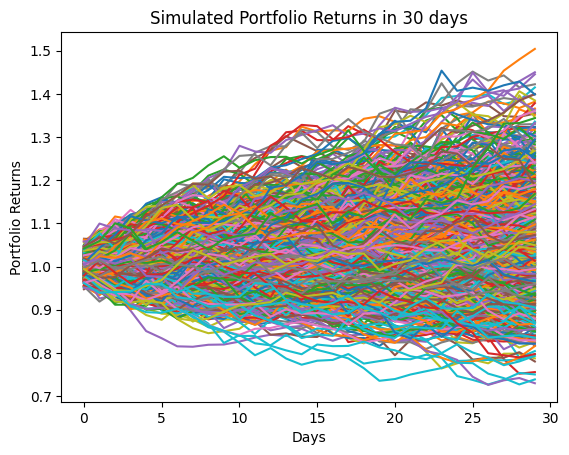

In [38]:
# Visualizing the result

plt.plot(portf_returns_30_m)
plt.ylabel('Portfolio Returns')
plt.xlabel('Days')
plt.title('Simulated Portfolio Returns in 30 days')
plt.show()

In [39]:
# Porfolio Returns statistics on the 30th day
Avg_portf_returns = np.mean(portf_returns_30_m[29,:]-1)
SD_portf_returns = np.std(portf_returns_30_m[29,:]-1)
Median_portf_returns = np.median(portf_returns_30_m[29,:]-1)
print(Avg_portf_returns)
print(SD_portf_returns)
print(Median_portf_returns)

0.06151639132625324
0.11915276838817747
0.05442027038727271


In [40]:
# construct CI for average
Avg_CI = np.quantile(portf_returns_30_m[29,:]-1,np.array([0.025,0.975]))
print(Avg_CI)

[-0.15812806  0.32001823]


For our particular example, the portfolio returns averaged over all monte carlo trials had an average close to 0. The reason the average is close to 0 is because Apple, Facebook, and Google have average returns close to 0 over the past year. Therefore, our simulated returns essentially had no drift. Also, assuming a normal distribution of the returns would not work well in practice since stock returns are typically fat-tailed and not normally distributed. However, based on our Monte Carlo Study, we do not suggest investing in this portfolio based on the low expected portfolio returns.